# Model Evaluation

In this notebook, we evaluate the trained machine learning models using various performance metrics and visualization techniques.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [2]:
X_test = pd.read_csv(
    r"C:\Users\athar\OneDrive\Desktop\credit\data\processed\X_test.csv"
)

y_test = pd.read_csv(
    r"C:\Users\athar\OneDrive\Desktop\credit\data\processed\Y_test.csv"
).squeeze()

In [3]:
lr_model = joblib.load(
    r"C:\Users\athar\OneDrive\Desktop\credit\models\logistic_regression.pkl"
)

rf_model = joblib.load(
    r"C:\Users\athar\OneDrive\Desktop\credit\models\random_forest.pkl"
)

xgb_model = joblib.load(
    r"C:\Users\athar\OneDrive\Desktop\credit\models\xgboost.pkl"
)

## Make Predictions

In [4]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [5]:
lr_prob = lr_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

## Performance Metrics

In [6]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall   :", recall_score(y_true,y_pred))
    print("F1 Score :", f1_score(y_true,y_pred))
    print("ROC AUC  :", roc_auc_score(y_true,y_prob))

    print("\nClassification Report\n")

    print(classification_report(y_true,y_pred))

In [7]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

Logistic Regression
Accuracy : 0.9991748885221726
Precision: 0.8148148148148148
Recall   : 0.673469387755102
F1 Score : 0.7374301675977654
ROC AUC  : 0.9470229003250147

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.67      0.74        98

    accuracy                           1.00     56962
   macro avg       0.91      0.84      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest
Accuracy : 0.9996137776061234
Precision: 0.9418604651162791
Recall   : 0.826530612244898
F1 Score : 0.8804347826086957
ROC AUC  : 0.9623458908042677

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.

## Confusion Matrix

In [9]:
def plot_confusion_matrix(title,y_true,y_pred):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

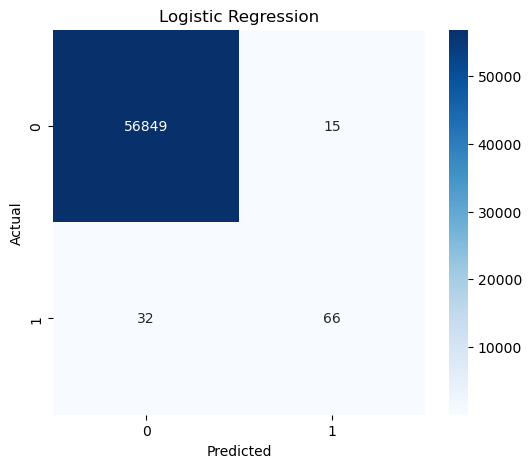

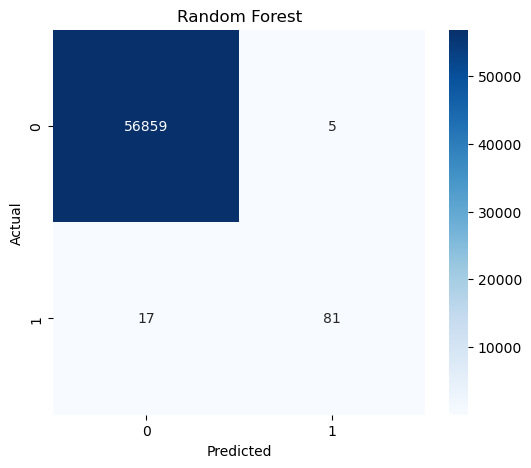

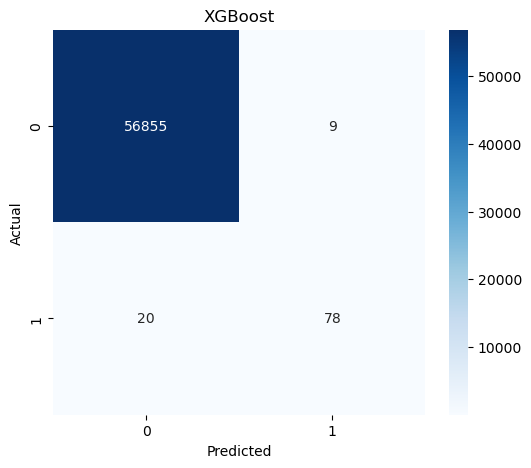

In [10]:
plot_confusion_matrix(
    "Logistic Regression",
    y_test,
    lr_pred
)

plot_confusion_matrix(
    "Random Forest",
    y_test,
    rf_pred
)

plot_confusion_matrix(
    "XGBoost",
    y_test,
    xgb_pred
)

## ROC Curve

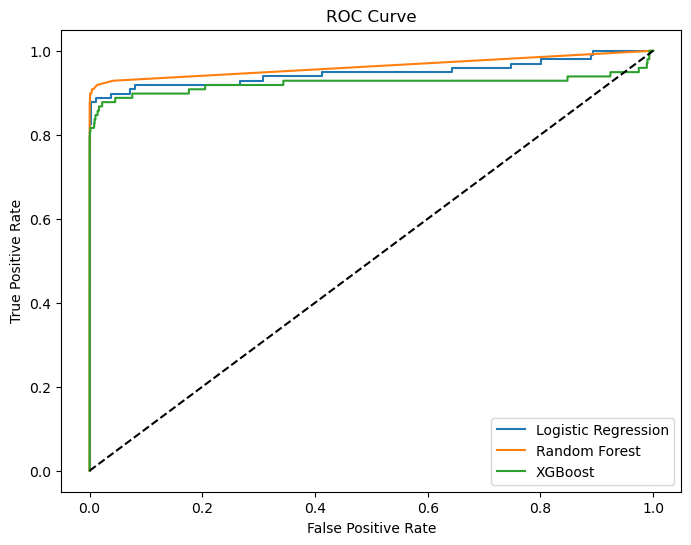

In [11]:
plt.figure(figsize=(8,6))

for name,prob in [
    ("Logistic Regression",lr_prob),
    ("Random Forest",rf_prob),
    ("XGBoost",xgb_prob)
]:

    fpr,tpr,_ = roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Precision-Recall Curve

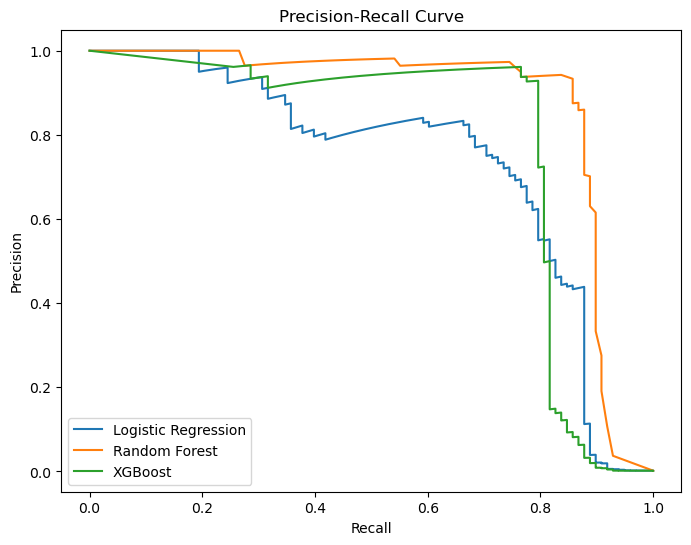

In [12]:
plt.figure(figsize=(8,6))

for name,prob in [
    ("Logistic Regression",lr_prob),
    ("Random Forest",rf_prob),
    ("XGBoost",xgb_prob)
]:

    precision,recall,_ = precision_recall_curve(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

In [13]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,xgb_pred)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999175,0.814815,0.673469,0.737430
1,Random Forest,0.999614,0.941860,0.826531,0.880435
2,XGBoost,0.999491,0.896552,0.795918,0.843243


# Conclusion

The trained models were evaluated using multiple classification metrics.

Since the dataset is highly imbalanced, metrics such as **Precision, Recall, F1-Score, and ROC-AUC** provide a more reliable assessment than accuracy alone.

Based on these results, the best-performing model can be selected for deployment in the Streamlit application.